In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
# Load features list
features = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None)
feature_names = features.iloc[:, 1].tolist()

# Load activity labels
activity_labels = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep='\s+', header=None)
activity_labels.columns = ['Label', 'Activity']

# Load Training data
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
X_train.columns = feature_names
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None)

# Load Testing data
X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None )
X_test.columns = feature_names
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt', sep='\s+', header=None)

X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)
y.columns = ['Label']
y = y.merge(activity_labels, on='Label', how='left')

print("Shape of Dataset:", X.shape)
print("Missing values in dataset:", X.isnull().sum().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Shape of Dataset: (10299, 561)
Missing values in dataset: 0


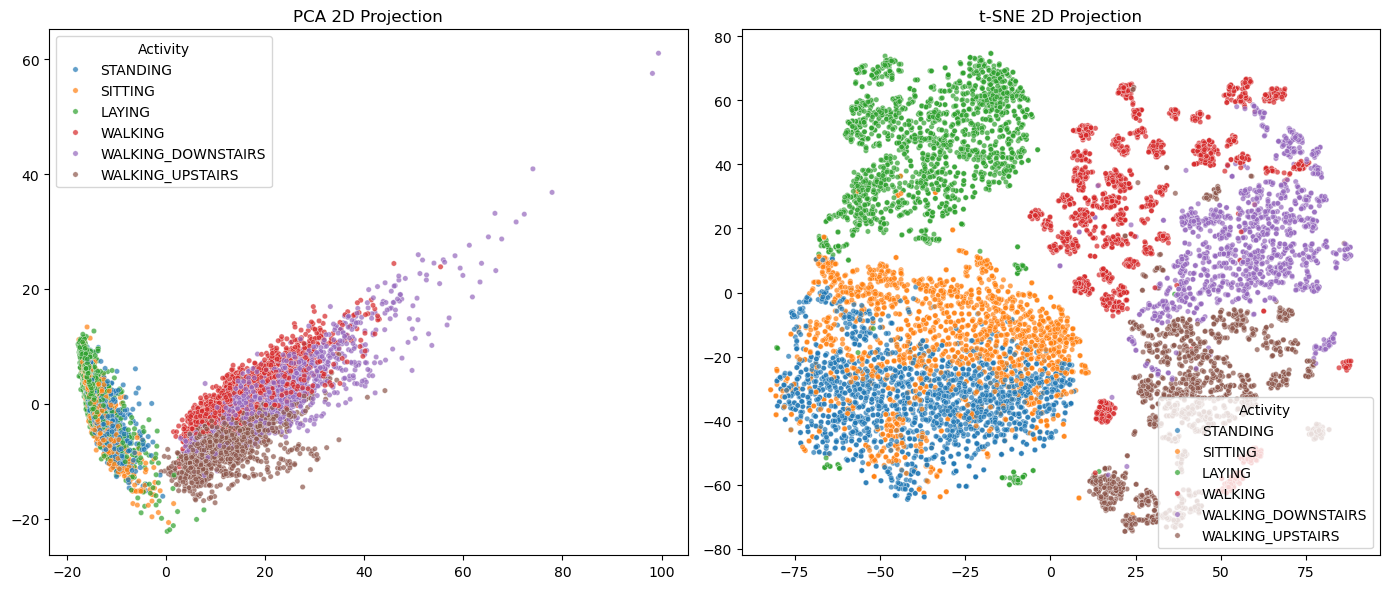

In [12]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled) 
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_scaled)
X_tsne = tsne.fit_transform(X_pca_50)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y['Activity'], palette='tab10', s=15, alpha=0.7)
plt.title('PCA 2D Projection')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y['Activity'], palette='tab10', s=15, alpha=0.7)
plt.title('t-SNE 2D Projection')

plt.tight_layout()
plt.show()

In [13]:
k_values = range(2, 9)
wcss = []
silhouette_scores = []
results = []

# Using X_pca_50 to reduce noise and computation time compared to 561 features
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_50)
    
    wcss_score = kmeans.inertia_
    sil_score = silhouette_score(X_pca_50, labels)
    
    wcss.append(wcss_score)
    silhouette_scores.append(sil_score)
    
    results.append({
        'Number of Clusters (k)': k,
        'WCSS (Inertia)': round(wcss_score, 2),
        'Silhouette Score': round(sil_score, 4)
    })

# Table 1: K-Means Elbow Method Results
table1 = pd.DataFrame(results)
display(table1)

,Number of Clusters (k),WCSS (Inertia),Silhouette Score
0,2,2527535.19,0.4501
1,3,2176124.28,0.3678
2,4,2036867.90,0.1903
3,5,1911005.10,0.1662
4,6,1833594.70,0.1524
5,7,1776514.72,0.1227
6,8,1722452.60,0.1162


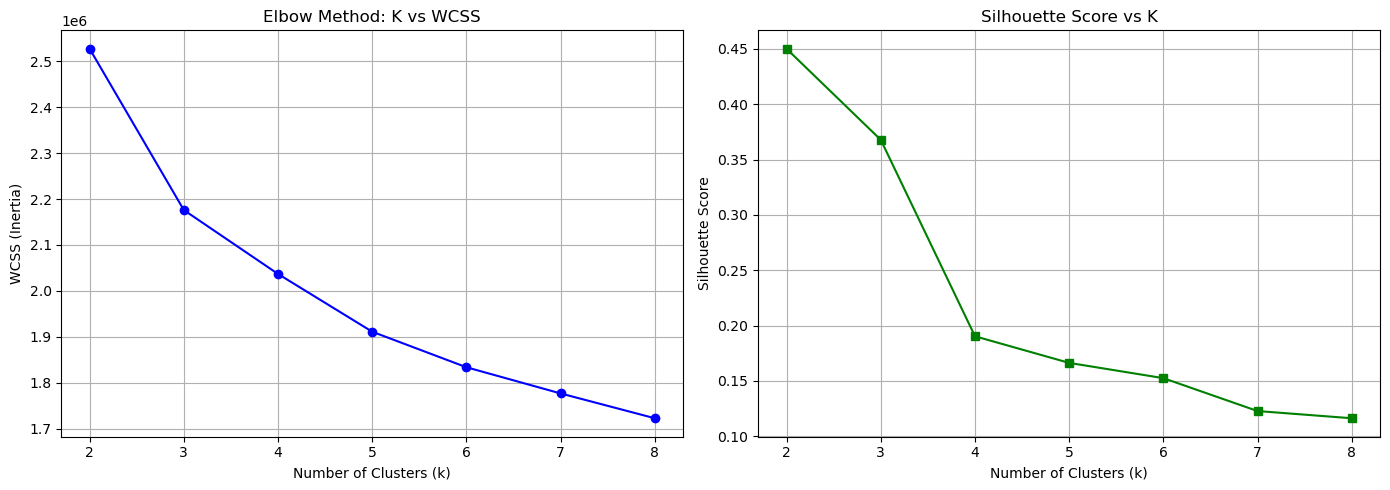

In [14]:
plt.figure(figsize=(14, 5))

# Plot k vs WCSS (Elbow Curve)
plt.subplot(1, 2, 1)
plt.plot(k_values, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method: K vs WCSS')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)

# Plot k vs Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='s', linestyle='-', color='g')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels = kmeans_6.fit_predict(X_pca_50)

In [16]:
eps_val = 14.0 
min_pts_val = 10

dbscan = DBSCAN(eps=eps_val, min_samples=min_pts_val)
dbscan_labels = dbscan.fit_predict(X_pca_50)

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN Clusters: {n_dbscan_clusters}")
print(f"Noise Points: {n_noise} out of {len(X_pca_50)}")

DBSCAN Clusters: 2
Noise Points: 660 out of 10299


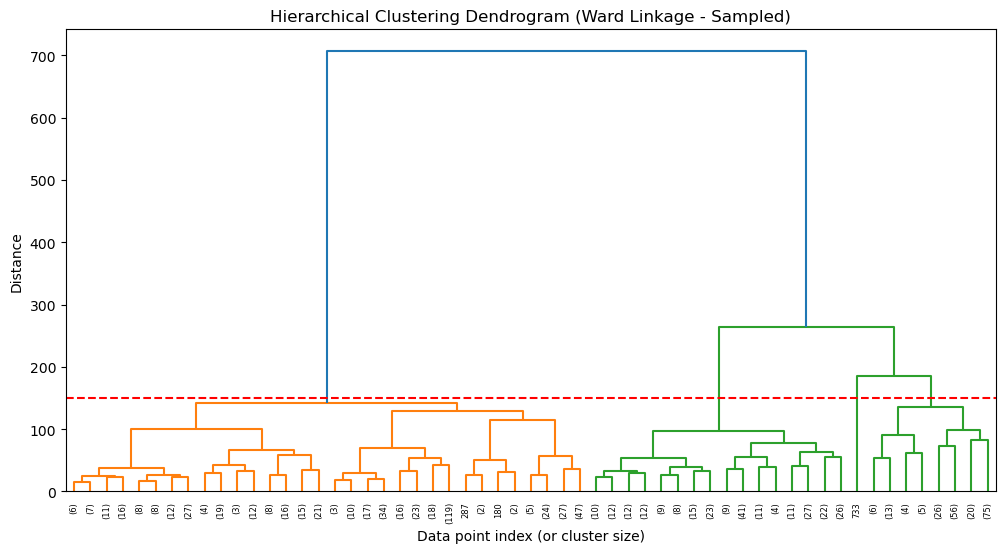

In [17]:

np.random.seed(42)
sample_idx = np.random.choice(X_pca_50.shape[0], size=1000, replace=False)
X_sample = X_pca_50[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage - Sampled)')
plt.xlabel('Data point index (or cluster size)')
plt.ylabel('Distance')
dendrogram(Z, truncate_mode='level', p=5, show_leaf_counts=True)
plt.axhline(y=150, color='r', linestyle='--')
plt.show()

# Apply Agglomerative Clustering using Ward's linkage for k=6
hac = AgglomerativeClustering(n_clusters=6, linkage='ward')
hac_labels = hac.fit_predict(X_pca_50)

In [18]:
def compute_metrics(algo, labels, X, y_true):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return {'Algorithm': algo, 'Silhouette': 0, 'Davies-Bouldin': 0, 'Calinski-Harabasz': 0, 'ARI': 0, 'NMI': 0}
        
    return {
        'Algorithm': algo,
        'Silhouette': silhouette_score(X, labels),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels),
        'ARI': adjusted_rand_score(y_true, labels),
        'NMI': normalized_mutual_info_score(y_true, labels)
    }

metrics = [
    compute_metrics('K-Means (k=6)', kmeans_labels, X_pca_50, y['Label']),
    compute_metrics('DBSCAN', dbscan_labels, X_pca_50, y['Label']),
    compute_metrics('Hierarchical (Ward, k=6)', hac_labels, X_pca_50, y['Label'])
]

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means (k=6),0.152444,1.968146,3591.285346,0.420093,0.559792
1,DBSCAN,0.324938,1.435599,805.265184,0.013575,0.060240
2,"Hierarchical (Ward, k=6)",0.129356,2.064510,3292.688217,0.421752,0.579220


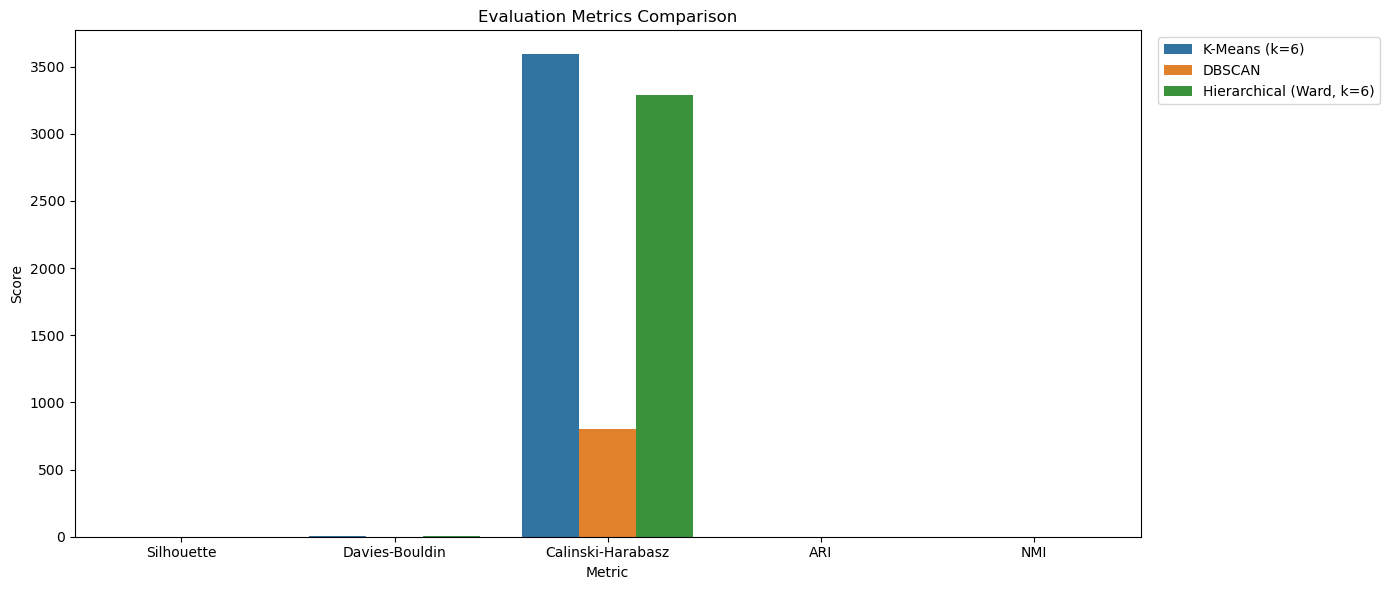

In [19]:
# Bar plots of evaluation metrics across algorithms
metrics_melted = pd.melt(metrics_df, id_vars=['Algorithm'], var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=metrics_melted)
plt.title('Evaluation Metrics Comparison')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

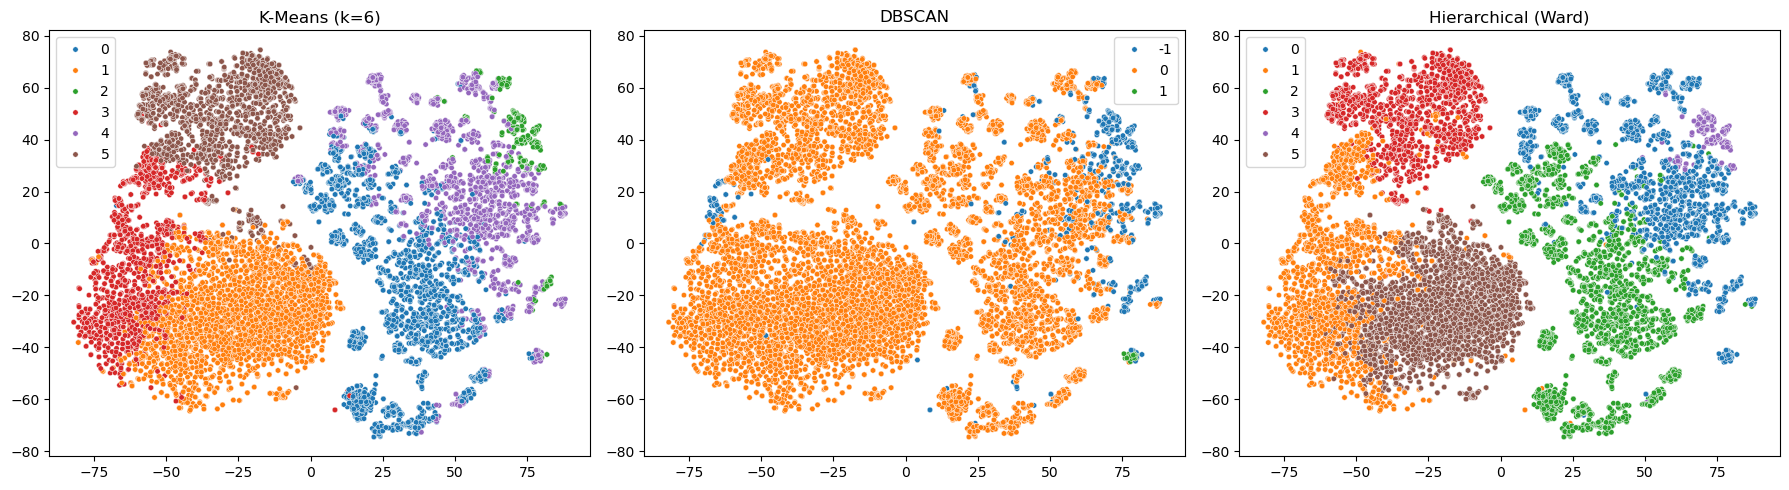

In [20]:
plt.figure(figsize=(18, 5))

# K-Means
plt.subplot(1, 3, 1)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_labels, palette='tab10', s=15, legend='full')
plt.title('K-Means (k=6)')

# DBSCAN
plt.subplot(1, 3, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=dbscan_labels, palette='tab10', s=15, legend='full')
plt.title('DBSCAN')

# Hierarchical
plt.subplot(1, 3, 3)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=hac_labels, palette='tab10', s=15, legend='full')
plt.title('Hierarchical (Ward)')

plt.tight_layout()
plt.show()